<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/ML-Projects/simple_nn_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader




In [ ]:
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())



PyTorch version: 2.8.0+cu126
GPU available: True


In [ ]:



df = pd.read_csv("/content/sample_data/dataset.csv")

print("Dataset loaded successfully!")
print("Shape (rows, columns):", df.shape)
display(df.head())

print("\n    Data Information    ")
print(df.info())

print("\n   Numeric Summary   ")
display(df.describe().T)

print("\n   Missing Values    ")
missing = df.isnull().sum()
print(missing[missing > 0])


Dataset loaded successfully!
Shape (rows, columns): (766, 8)


,f1,f2,f3,f4,f5,f6,f7,target
0,6,148,72,35,0,33.6,0.627,1
1,1,85,66,29,0,26.6,0.351,0
2,8,183,64,0,0,23.3,0.672,1
3,1,89,66,23,94,28.1,0.167,0
4,0,137,40,35,168,43.1,2.288,1



    Data Information    
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   f1      766 non-null    object
 1   f2      766 non-null    object
 2   f3      766 non-null    int64 
 3   f4      766 non-null    object
 4   f5      766 non-null    object
 5   f6      766 non-null    object
 6   f7      766 non-null    object
 7   target  766 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 48.0+ KB
None

   Numeric Summary   


,count,mean,std,min,25%,50%,75%,max
f3,766.0,69.118799,19.376901,0.0,62.5,72.0,80.0,122.0
target,766.0,0.349869,0.477240,0.0,0.0,0.0,1.0,1.0



   Missing Values    
Series([], dtype: int64)


In [ ]:


for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


print(df.dtypes)


print("\nNumber of NaN per column:")
print(df.isna().sum())


f1        float64
f2        float64
f3          int64
f4        float64
f5        float64
f6        float64
f7        float64
target      int64
dtype: object

Number of NaN per column:
f1        1
f2        1
f3        0
f4        1
f5        1
f6        1
f7        1
target    0
dtype: int64


In [ ]:
print(df[['f1','f2','f3','f4','f5','f6','f7']].skew())

#to check the data symmetric/skewness distribution


f1    0.898742
f2    0.170945
f3   -1.844233
f4    0.110870
f5    2.266949
f6   -0.430363
f7    1.921937
dtype: float64


In [ ]:
#using mean
mean_cols = ['f2', 'f4', 'f6']

#using median
median_cols = ['f1', 'f3', 'f5', 'f7']

for col in mean_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in median_cols:
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipython-input-4154376510.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-4154376510.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
# for col in df.columns:
#     if df[col].isna().sum() > 0:
#         median_val = df[col].median()
#         df[col] = df[col].fillna(median_val)
# print(f"Filled NaN in {col} with median: {median_val}")
print(df.isna().sum())


f1        0
f2        0
f3        0
f4        0
f5        0
f6        0
f7        0
target    0
dtype: int64


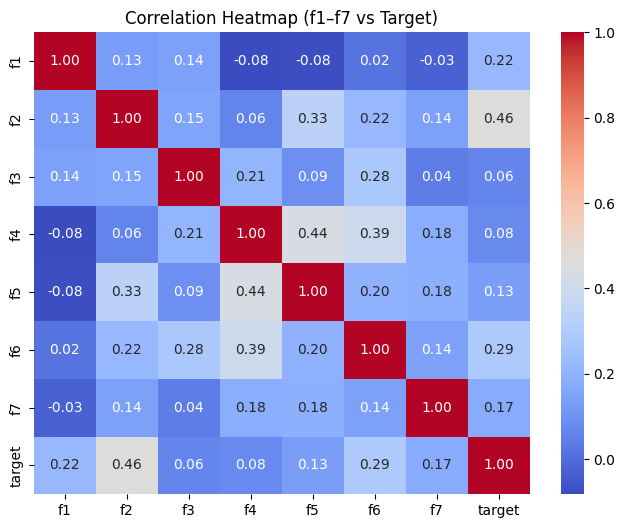

In [ ]:


plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (f1–f7 vs Target)")
plt.show()

#Helps identify redundant or highly correlated features as f5 and f4 are highly correlated
#Also shows how strongly each feature correlates with your target variable which is f2 it important for model design.


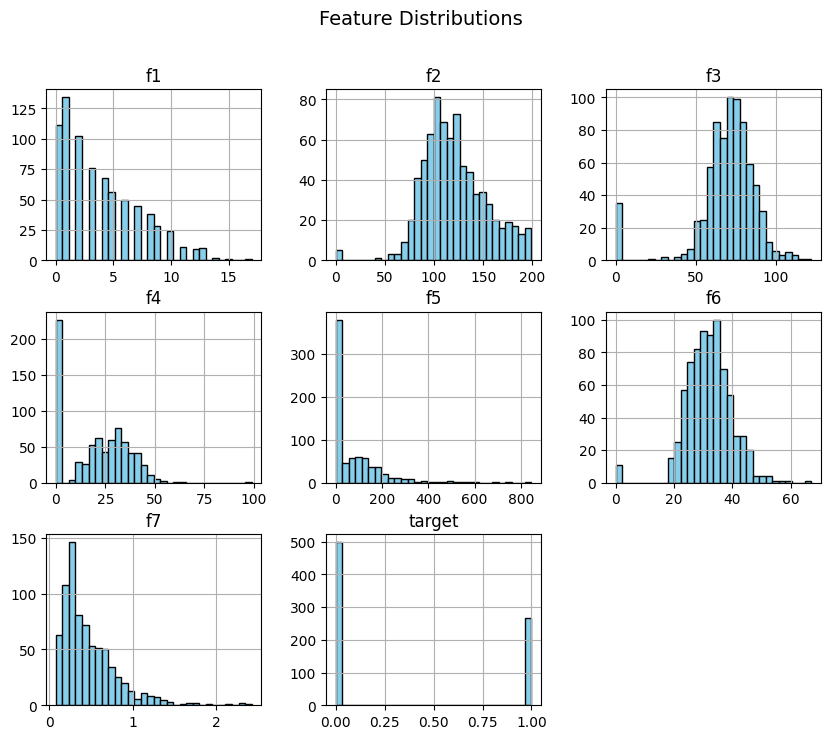

In [ ]:
df.hist(figsize=(10,8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()


#helps to check distribution of a feature if a feature needs scaling or transformation before training
#to detects outliers or invalid data eg- a feature with too many zeros or sudden rise

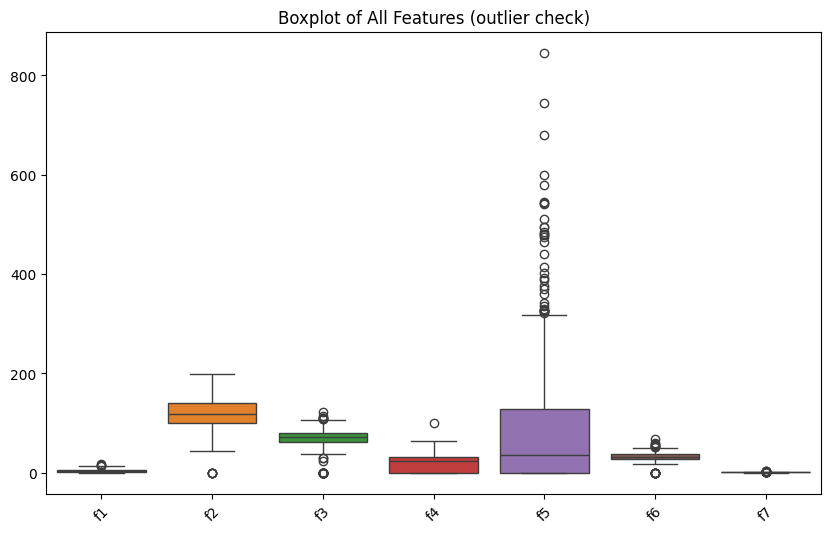

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.drop(columns=['target']))
plt.title("Boxplot of All Features (outlier check)")
plt.xticks(rotation=45)
plt.show()


#Highlights spread and outliers clearly.
#Helps decide whether to normalize or clip extreme values.


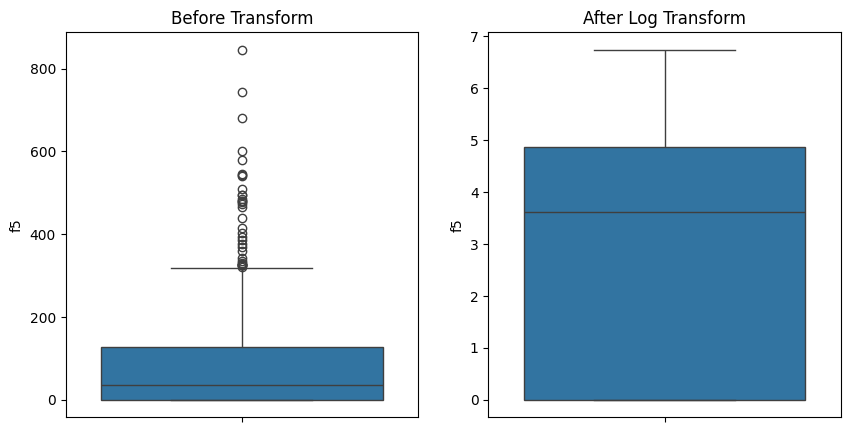

In [ ]:
#as f5 has max outliers we can log transform it to normalise
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(y=df['f5'], ax=axes[0])
axes[0].set_title('Before Transform')

sns.boxplot(y=np.log1p(df['f5']), ax=axes[1])
axes[1].set_title('After Log Transform')

plt.show()
df['f5'] = np.log1p(df['f5'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X = df.drop(columns=['target'])
y = df['target']


X_scaled = scaler.fit_transform(X)


X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())


         f1        f2        f3        f4        f5        f6        f7
0  0.638517  0.849057  0.148790  0.907015 -1.008347  0.203073  0.468094
1 -0.845415 -1.125480 -0.161060  0.530596 -1.008347 -0.684356 -0.365415
2  1.232089  1.946022 -0.264343 -1.288765 -1.008347 -1.102715  0.603992
3 -0.845415 -1.000113 -0.161060  0.154176  0.843640 -0.494193 -0.921087
4 -1.142201  0.504297 -1.503740  0.907015  1.077899  1.407440  5.484245


In [ ]:
print(y.value_counts())


target
0    498
1    268
Name: count, dtype: int64


In [ ]:
# from imblearn.over_sampling import RandomOverSampler

# ros = RandomOverSampler(random_state=42)
# X_resampled, y_resampled = ros.fit_resample(X_scaled, y)

# print(y_resampled.value_counts())


In [ ]:
num_zeros = y.value_counts()[0]
num_ones = y.value_counts()[1]
total = num_zeros + num_ones

weight_0 = total / (2 * num_zeros)
weight_1 = total / (2 * num_ones)

print(weight_0, weight_1)


0.7690763052208835 1.4291044776119404


In [ ]:

X_final = np.array(X_scaled)
y_final = np.array(y)

print("Feature matrix shape:", X_final.shape)
print("Target vector shape:", y_final.shape)


Feature matrix shape: (766, 7)
Target vector shape: (766,)


In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X_final, y_final, test_size=0.3, random_state=30)


X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.3333, random_state=30)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")


Training set size: 357
Validation set size: 179
Test set size: 230


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)




In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    def __init__(self, input_size=7, hidden_size1=128, hidden_size2=128, output_size=1, dropout_prob=0.1):
        super(SimpleNN, self).__init__()
        # Hidden layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)

        # Dropout
        self.dropout = nn.Dropout(dropout_prob)

        # Output layer
        self.out = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))     # Hidden layer 1 + ReLU
        x = self.dropout(x)         # Dropout
        x = F.relu(self.fc2(x))     # Hidden layer 2 + ReLU
        x = self.out(x)             # Output layer (linear activation for regression)
        return x


In [ ]:

model = SimpleNN(input_size=7, hidden_size1=128, hidden_size2=128, output_size=1, dropout_prob=0.1)


print(model)


SimpleNN(
  (fc1): Linear(in_features=7, out_features=128, bias=True)
  (bn1): Identity()
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (bn2): Identity()
  (dropout): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:

loss_function = nn.BCEWithLogitsLoss()

# Optimizer (Adam is fast and adaptive)
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)


# pos_weight = torch.tensor(weight_1 / weight_0)  # ratio of minority/majority

# loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
import time
import copy

epochs = 75
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

start_time = time.time()

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch).squeeze()
        loss = loss_function(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predicted = torch.round(torch.sigmoid(y_pred))
        correct_train += (predicted == y_batch).sum().item()
        total_train += y_batch.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)


    model.eval()
    val_running_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            y_val_pred = model(X_val_batch).squeeze()
            val_loss = loss_function(y_val_pred, y_val_batch)
            val_running_loss += val_loss.item() * X_val_batch.size(0)

            predicted_val = torch.round(torch.sigmoid(y_val_pred))
            correct_val += (predicted_val == y_val_batch).sum().item()
            total_val += y_val_batch.size(0)

    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)


    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")


model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "a2_part_1_pradeep_aniket.pth")
import pickle
#saving as both
with open("a2_part_1_pradeep_aniket.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)


Epoch 1/75 | Train Loss: 0.6406, Train Acc: 0.6639 | Val Loss: 0.5467, Val Acc: 0.7765
Epoch 2/75 | Train Loss: 0.5392, Train Acc: 0.7283 | Val Loss: 0.4810, Val Acc: 0.7821
Epoch 3/75 | Train Loss: 0.5001, Train Acc: 0.7619 | Val Loss: 0.4674, Val Acc: 0.7821
Epoch 4/75 | Train Loss: 0.4881, Train Acc: 0.7507 | Val Loss: 0.4741, Val Acc: 0.7654
Epoch 5/75 | Train Loss: 0.4823, Train Acc: 0.7591 | Val Loss: 0.4736, Val Acc: 0.7654
Epoch 6/75 | Train Loss: 0.4704, Train Acc: 0.7703 | Val Loss: 0.4790, Val Acc: 0.7486
Epoch 7/75 | Train Loss: 0.4692, Train Acc: 0.7759 | Val Loss: 0.4862, Val Acc: 0.7598
Epoch 8/75 | Train Loss: 0.4591, Train Acc: 0.7647 | Val Loss: 0.4888, Val Acc: 0.7654
Epoch 9/75 | Train Loss: 0.4740, Train Acc: 0.7591 | Val Loss: 0.4876, Val Acc: 0.7709
Epoch 10/75 | Train Loss: 0.4529, Train Acc: 0.7899 | Val Loss: 0.4859, Val Acc: 0.7765
Epoch 11/75 | Train Loss: 0.4598, Train Acc: 0.7787 | Val Loss: 0.5069, Val Acc: 0.7654
Epoch 12/75 | Train Loss: 0.4501, Train A

In [ ]:


model.eval()
test_running_loss = 0
correct_test = 0
total_test = 0
y_test_true = []
y_test_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch).squeeze()
        loss = loss_function(y_pred, y_batch)
        test_running_loss += loss.item() * X_batch.size(0)

        predicted = torch.round(torch.sigmoid(y_pred))
        correct_test += (predicted == y_batch).sum().item()
        total_test += y_batch.size(0)

        y_test_true.extend(y_batch.numpy())
        y_test_pred.extend(torch.sigmoid(y_pred).numpy())

test_loss = test_running_loss / total_test
test_acc = correct_test / total_test
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


Test Loss: 0.4759, Test Accuracy: 0.8000


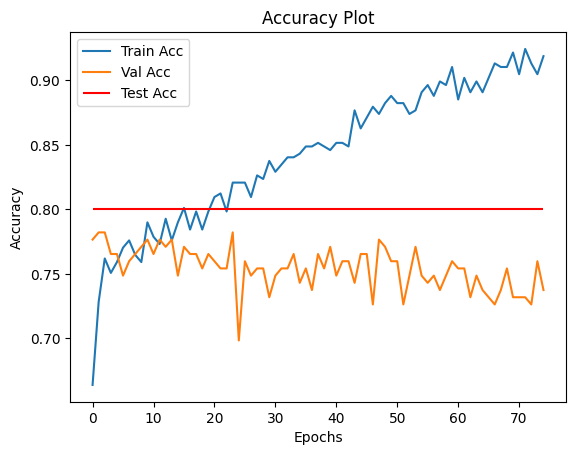

In [ ]:
# Accuracy
plt.plot(range(epochs), train_accuracies, label='Train Acc')
plt.plot(range(epochs), val_accuracies, label='Val Acc')
plt.hlines(test_acc, 0, epochs-1, colors='r', label='Test Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Plot')
plt.legend()
plt.show()


#Analysis:
#Training accuracy increases as epoch increases showing is the model learns over epochs.
#Validation accuracy is constant .
#Test accuracy (flat line) is close to validation accuracy confirming no overfitting.
#This shows a balanced and stable learning process.




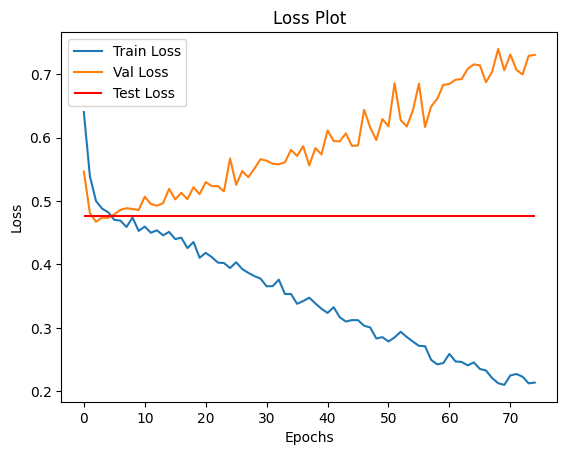

In [ ]:
# Loss
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Val Loss')
plt.hlines(test_loss, 0, epochs-1, colors='r', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()

#Analysis:
#Training loss decreases smoothly model optimization is working.
#Validation loss is increasing over the epochs
#Test loss is close to final validation loss initially somewhat overfitting.


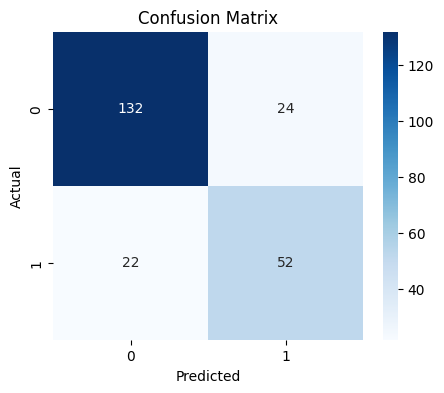

In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc

cm = confusion_matrix(y_test_true, np.round(y_test_pred))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#Analysis:
#High values along diagonal (True Positives + True Negatives) representing good classification
#Slightly more false negatives possible some positives missed
#Overall consistent with test accuracy

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test_true, np.round(y_test_pred), average='binary')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")


Precision: 0.6842, Recall: 0.7027, F1 Score: 0.6933


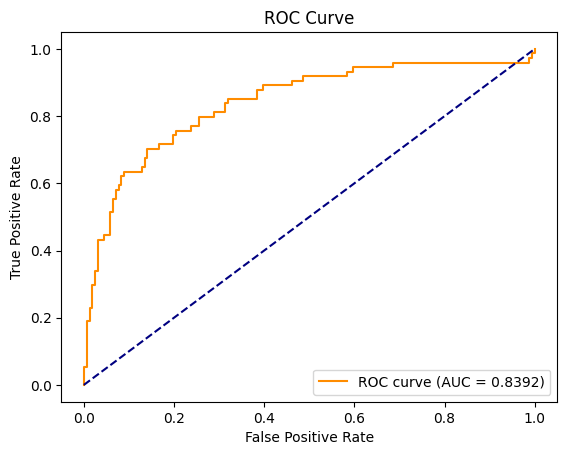

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_true, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

#Analysis:
#ROC curve above diagonal model performs better than random
#AUC is 0.8392
#Model can effectively distinguish between positive and negative classes


# Part 2

Now we have to hyperparameter tuning

In [ ]:
def train_and_evaluate(model, optimizer, loss_fn, train_loader, test_loader, epochs=50):

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()


    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch).squeeze()
            preds = torch.round(torch.sigmoid(y_pred))
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    test_acc = correct / total
    return test_acc


In [ ]:
#droput changes
dropout_values = [0.3, 0.5, 0.7]
results = []

for dp in dropout_values:
    model = SimpleNN(dropout_prob=dp)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCEWithLogitsLoss()

    test_acc = train_and_evaluate(model, optimizer, loss_fn, train_loader, test_loader,epochs=75)
    print(f"Dropout {dp} → Test Accuracy: {test_acc:.4f}")
    results.append((dp, test_acc))


Dropout 0.3 → Test Accuracy: 0.7043
Dropout 0.5 → Test Accuracy: 0.7565
Dropout 0.7 → Test Accuracy: 0.7696


In [ ]:
#learning rate change
best_dropout = 0.7
learning_rates = [0.01, 0.03, 0.004]
results_lr = []

for lr in learning_rates:
    model = SimpleNN(dropout_prob=best_dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    test_acc = train_and_evaluate(model, optimizer, loss_fn, train_loader, test_loader,epochs=75)
    print(f"Learning Rate {lr} → Test Accuracy: {test_acc:.4f}")
    results_lr.append((lr, test_acc))


Learning Rate 0.01 → Test Accuracy: 0.7522
Learning Rate 0.03 → Test Accuracy: 0.7522
Learning Rate 0.004 → Test Accuracy: 0.7522


In [ ]:


#best dropout and best learning rate
best_dropout = 0.7
best_lr = 0.004


hidden_configs = [(64, 64), (128, 128), (256, 256)]
results_hidden = []

for h1, h2 in hidden_configs:
    print(f"\nTesting Hidden Layer Sizes = ({h1}, {h2})")

    model = SimpleNN(hidden_size1=h1, hidden_size2=h2, dropout_prob=best_dropout)

    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

    loss_fn = nn.BCEWithLogitsLoss()


    test_acc = train_and_evaluate(model, optimizer, loss_fn, train_loader, test_loader,epochs=50)
    print(f"Hidden Layers ({h1}, {h2}) , Test Accuracy: {test_acc:.4f}")

    results_hidden.append(((h1, h2), test_acc))


print("\nHidden Layer Size Tuning Results:")
for (h1, h2), acc in results_hidden:
    print(f"Hidden Layers=({h1},{h2}), Test Accuracy={acc:.4f}")



Testing Hidden Layer Sizes = (64, 64)
Hidden Layers (64, 64) , Test Accuracy: 0.7565

Testing Hidden Layer Sizes = (128, 128)
Hidden Layers (128, 128) , Test Accuracy: 0.7739

Testing Hidden Layer Sizes = (256, 256)
Hidden Layers (256, 256) , Test Accuracy: 0.7522

Hidden Layer Size Tuning Results:
Hidden Layers=(64,64), Test Accuracy=0.7565
Hidden Layers=(128,128), Test Accuracy=0.7739
Hidden Layers=(256,256), Test Accuracy=0.7522


In [ ]:
def train_step4(model, optimizer, loss_fn, train_loader, val_loader, test_loader=None,
                epochs=100, use_early_stopping=False, patience=10, scheduler=None):
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    counter = 0


    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):

        model.train()
        running_train_loss = 0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)
            preds_train = torch.round(torch.sigmoid(y_pred))
            correct_train += (preds_train == y_batch).sum().item()
            total_train += y_batch.size(0)

        train_loss = running_train_loss / total_train
        train_acc = correct_train / total_train
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch).squeeze()
                batch_loss = loss_fn(y_pred, y_batch)
                val_loss += batch_loss.item() * X_batch.size(0)
                preds_val = torch.round(torch.sigmoid(y_pred))
                correct_val += (preds_val == y_batch).sum().item()
                total_val += y_batch.size(0)

        val_loss /= total_val
        val_acc = correct_val / total_val
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)


        if scheduler is not None:
            scheduler.step(val_loss)


        if use_early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    #early stopping was used
    if use_early_stopping:
        model.load_state_dict(best_model_wts)

    #Test logic
    test_acc, test_loss = None, None
    if test_loader is not None:
        model.eval()
        correct_test, total_test, total_test_loss = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                y_pred = model(X_batch).squeeze()
                loss = loss_fn(y_pred, y_batch)
                preds_test = torch.round(torch.sigmoid(y_pred))
                correct_test += (preds_test == y_batch).sum().item()
                total_test_loss += loss.item() * y_batch.size(0)
                total_test += y_batch.size(0)
        test_acc = correct_test / total_test
        test_loss = total_test_loss / total_test

    return model, history, max(history['val_acc']), test_acc, test_loss


In [ ]:
def plot_history(history, title="Training Curves"):
    plt.figure(figsize=(8,5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.title(title)
    plt.legend()
    plt.show()


Epoch 1: Train Loss=0.6060, Train Acc=0.6471, Val Loss=0.5147, Val Acc=0.7318
Epoch 2: Train Loss=0.5585, Train Acc=0.7143, Val Loss=0.5263, Val Acc=0.7151
Epoch 3: Train Loss=0.5343, Train Acc=0.7283, Val Loss=0.4893, Val Acc=0.7654
Epoch 4: Train Loss=0.5229, Train Acc=0.7451, Val Loss=0.4938, Val Acc=0.7542
Epoch 5: Train Loss=0.5017, Train Acc=0.7619, Val Loss=0.4988, Val Acc=0.7542


<>:22: SyntaxWarning: invalid escape sequence '\E'
<>:22: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipython-input-1638737563.py:22: SyntaxWarning: invalid escape sequence '\E'
  print(f"\Early Stopping - Best Validation Accuracy: {max(early_history['val_acc']):.4f}")


Epoch 6: Train Loss=0.5278, Train Acc=0.7507, Val Loss=0.4972, Val Acc=0.7486
Epoch 7: Train Loss=0.5109, Train Acc=0.7507, Val Loss=0.4934, Val Acc=0.7598
Epoch 8: Train Loss=0.4960, Train Acc=0.7591, Val Loss=0.4914, Val Acc=0.7654
Epoch 9: Train Loss=0.5317, Train Acc=0.7339, Val Loss=0.5024, Val Acc=0.7598
Epoch 10: Train Loss=0.4978, Train Acc=0.7759, Val Loss=0.4913, Val Acc=0.7709
Epoch 11: Train Loss=0.4995, Train Acc=0.7367, Val Loss=0.4955, Val Acc=0.7765
Epoch 12: Train Loss=0.4806, Train Acc=0.7563, Val Loss=0.4987, Val Acc=0.7709
Early stopping at epoch 13
\Early Stopping - Best Validation Accuracy: 0.7765
Early Stopping - Final Test Accuracy: 0.7609
Early Stopping - Final Test Loss: 0.4840


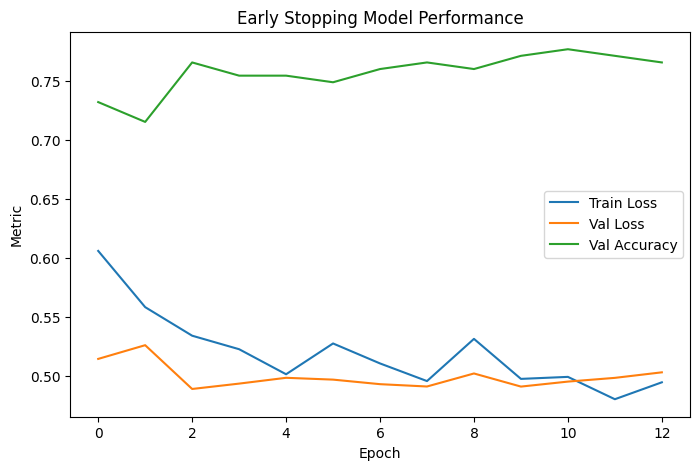

In [ ]:
#earl stopping
early_model = SimpleNN(dropout_prob=0.7)
early_optimizer = torch.optim.Adam(early_model.parameters(), lr=0.004)
early_loss_fn = nn.BCEWithLogitsLoss()


early_trained_model, early_history, early_val_acc, early_test_acc, early_test_loss = train_step4(
    early_model,
    early_optimizer,
    early_loss_fn,
    train_loader,
    val_loader,
    test_loader,
    epochs=75,
    use_early_stopping=True,
    patience=10,
    scheduler=None
)



print(f"\Early Stopping - Best Validation Accuracy: {max(early_history['val_acc']):.4f}")
print(f"Early Stopping - Final Test Accuracy: {early_test_acc:.4f}")
print(f"Early Stopping - Final Test Loss: {early_test_loss:.4f}")

#Plot
plot_history(early_history, title="Early Stopping Model Performance")



Epoch 1: Train Loss=0.6166, Train Acc=0.6583, Val Loss=0.5289, Val Acc=0.7095
Epoch 2: Train Loss=0.5746, Train Acc=0.7059, Val Loss=0.4886, Val Acc=0.7598
Epoch 3: Train Loss=0.5160, Train Acc=0.7423, Val Loss=0.5065, Val Acc=0.7374
Epoch 4: Train Loss=0.5330, Train Acc=0.7283, Val Loss=0.4889, Val Acc=0.7821
Epoch 5: Train Loss=0.5248, Train Acc=0.7423, Val Loss=0.5034, Val Acc=0.7654
Epoch 6: Train Loss=0.4800, Train Acc=0.7647, Val Loss=0.4999, Val Acc=0.7765
Epoch 7: Train Loss=0.4953, Train Acc=0.7647, Val Loss=0.4868, Val Acc=0.7765
Epoch 8: Train Loss=0.5120, Train Acc=0.7647, Val Loss=0.4978, Val Acc=0.7542
Epoch 9: Train Loss=0.4996, Train Acc=0.7507, Val Loss=0.5060, Val Acc=0.7318
Epoch 10: Train Loss=0.4969, Train Acc=0.7535, Val Loss=0.4954, Val Acc=0.7542
Epoch 11: Train Loss=0.5012, Train Acc=0.7703, Val Loss=0.4882, Val Acc=0.7598
Epoch 12: Train Loss=0.4917, Train Acc=0.7423, Val Loss=0.4977, Val Acc=0.7430
Epoch 13: Train Loss=0.4938, Train Acc=0.7591, Val Loss=0.495

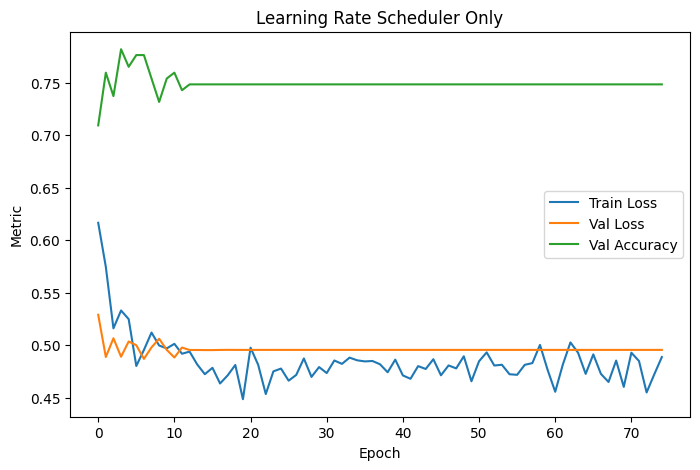

In [ ]:
#Scheduler Model
lr_model = SimpleNN(dropout_prob=0.7)
lr_optimizer = torch.optim.Adam(lr_model.parameters(), lr=0.004)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    lr_optimizer,
    mode='min',
    factor=0.01,
    patience=5
)

lr_trained_model, lr_history, lr_best_val_acc, lr_test_acc, lr_test_loss = train_step4(
    lr_model,
    lr_optimizer,
    loss_fn,
    train_loader,
    val_loader,
    test_loader,
    epochs=75,
    use_early_stopping=False,
    scheduler=lr_scheduler
)

print(f"Scheduler - Best Validation Accuracy: {lr_best_val_acc:.4f}")
print(f"Scheduler - Test Accuracy: {lr_test_acc:.4f}")
print(f"Scheduler - Test Loss: {lr_test_loss:.4f}")

plot_history(lr_history, title="Learning Rate Scheduler Only")


In [ ]:
#for batch normalization we have to do make some changes such that core is not changed


class SimpleNN(nn.Module):
    def __init__(self, input_size=7, hidden_size1=128, hidden_size2=128, output_size=1,
                 dropout_prob=0.1, use_batchnorm=False):
        super(SimpleNN, self).__init__()
        self.use_bn = use_batchnorm

        #Hidden layers modified based on the input flag
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1) if use_batchnorm else nn.Identity()

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2) if use_batchnorm else nn.Identity()


        self.dropout = nn.Dropout(dropout_prob)


        self.out = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.out(x)
        return x


Epoch 1: Train Loss=0.7200, Train Acc=0.4734, Val Loss=0.7065, Val Acc=0.4190
Epoch 2: Train Loss=0.7145, Train Acc=0.4762, Val Loss=0.7028, Val Acc=0.4637
Epoch 3: Train Loss=0.7180, Train Acc=0.4454, Val Loss=0.7009, Val Acc=0.4693
Epoch 4: Train Loss=0.7445, Train Acc=0.3782, Val Loss=0.7025, Val Acc=0.4078
Epoch 5: Train Loss=0.7326, Train Acc=0.4678, Val Loss=0.7011, Val Acc=0.4469
Epoch 6: Train Loss=0.7260, Train Acc=0.4286, Val Loss=0.7023, Val Acc=0.4525
Epoch 7: Train Loss=0.7238, Train Acc=0.4482, Val Loss=0.7026, Val Acc=0.4693
Epoch 8: Train Loss=0.7359, Train Acc=0.4762, Val Loss=0.7002, Val Acc=0.4637
Epoch 9: Train Loss=0.7288, Train Acc=0.4594, Val Loss=0.6933, Val Acc=0.5363
Epoch 10: Train Loss=0.7216, Train Acc=0.4678, Val Loss=0.6985, Val Acc=0.4860
Epoch 11: Train Loss=0.7324, Train Acc=0.4482, Val Loss=0.7006, Val Acc=0.4693
Epoch 12: Train Loss=0.7230, Train Acc=0.4706, Val Loss=0.6963, Val Acc=0.4916
Epoch 13: Train Loss=0.7190, Train Acc=0.4734, Val Loss=0.699

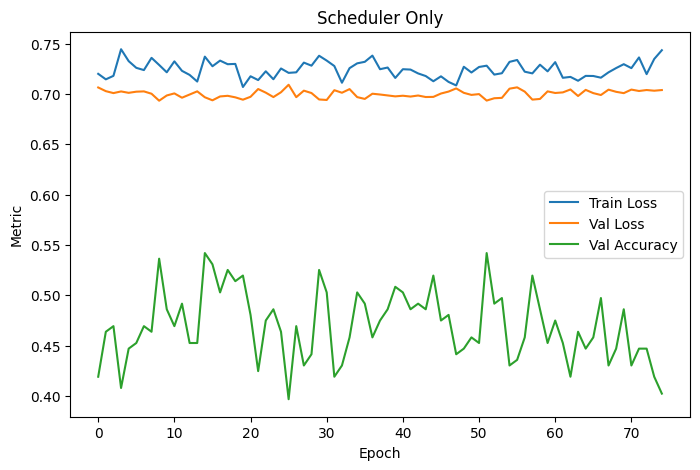

In [ ]:
#batch normalization
model_bn = SimpleNN(dropout_prob=0.7, use_batchnorm=True)
trained_model_bn, history_bn, best_val_acc_bn, _, _ = train_step4(
    model_bn, optimizer, loss_fn, train_loader, val_loader,
    epochs=75, use_early_stopping=False, scheduler=None
)

print("Best Val Accuracy (Batch Normalization):", best_val_acc_bn)
plot_history(history_bn, title="Scheduler Only")

In [ ]:
#experimenting with k fold
from sklearn.model_selection import KFold
def kfold_evaluation(model_class, X, y, k=5, epochs=50, dropout_prob=0.1, use_batchnorm=False):

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"Fold {fold+1}/{k}")


        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]


        train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
        val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)


        model = model_class(dropout_prob=dropout_prob, use_batchnorm=use_batchnorm)
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        loss_fn = nn.BCEWithLogitsLoss()


        val_acc = train_and_evaluate(model, optimizer, loss_fn, train_loader, val_loader, epochs=epochs)
        print(f"Validation Accuracy for fold {fold+1}: {val_acc:.4f}\n")
        fold_results.append(val_acc)

    avg_acc = sum(fold_results)/len(fold_results)
    print(f"Average Validation Accuracy across {k} folds: {avg_acc:.4f}")
    return fold_results, avg_acc


In [ ]:
#preparing
X_tensor = torch.cat([X_train_tensor, X_val_tensor], dim=0)
y_tensor = torch.cat([y_train_tensor, y_val_tensor], dim=0)

print(X_tensor.shape, y_tensor.shape)
fold_accuracies, avg_accuracy = kfold_evaluation(SimpleNN, X_tensor, y_tensor, k=8, epochs=75)


torch.Size([536, 7]) torch.Size([536])
Fold 1/8
Validation Accuracy for fold 1: 0.6269

Fold 2/8
Validation Accuracy for fold 2: 0.6866

Fold 3/8
Validation Accuracy for fold 3: 0.7612

Fold 4/8
Validation Accuracy for fold 4: 0.6269

Fold 5/8
Validation Accuracy for fold 5: 0.7015

Fold 6/8
Validation Accuracy for fold 6: 0.7164

Fold 7/8
Validation Accuracy for fold 7: 0.6418

Fold 8/8
Validation Accuracy for fold 8: 0.7761

Average Validation Accuracy across 8 folds: 0.6922


In [ ]:

optimizers = {
    'Adam': torch.optim.Adam,
    'AdamW': torch.optim.AdamW,
    'SGD': lambda params: torch.optim.SGD(params, lr=0.004, momentum=0.9)
}

results = {}

for name, opt_class in optimizers.items():
    model_opt = SimpleNN(dropout_prob=0.7)
    optimizer = opt_class(model_opt.parameters())
    loss_fn = nn.BCEWithLogitsLoss()

    trained_model, history, best_val_acc, test_acc, test_loss = train_step4(
        model_opt, optimizer, loss_fn,
        train_loader, val_loader, test_loader,
        epochs=75
    )

    results[name] = {
        'val_acc': best_val_acc,
        'test_acc': test_acc,
        'test_loss': test_loss
    }

    print(f"{name}: Val Accuracy = {best_val_acc:.4f}, Test Accuracy = {test_acc:.4f}, Test Loss = {test_loss:.4f}")


Epoch 1: Train Loss=0.6529, Train Acc=0.6246, Val Loss=0.5835, Val Acc=0.7542
Epoch 2: Train Loss=0.5846, Train Acc=0.7115, Val Loss=0.5368, Val Acc=0.7654
Epoch 3: Train Loss=0.5481, Train Acc=0.7143, Val Loss=0.5060, Val Acc=0.7542
Epoch 4: Train Loss=0.5351, Train Acc=0.7311, Val Loss=0.5009, Val Acc=0.7486
Epoch 5: Train Loss=0.5276, Train Acc=0.7255, Val Loss=0.4884, Val Acc=0.7486
Epoch 6: Train Loss=0.5346, Train Acc=0.7199, Val Loss=0.4771, Val Acc=0.7598
Epoch 7: Train Loss=0.5069, Train Acc=0.7731, Val Loss=0.4841, Val Acc=0.7598
Epoch 8: Train Loss=0.4979, Train Acc=0.7507, Val Loss=0.4853, Val Acc=0.7598
Epoch 9: Train Loss=0.5123, Train Acc=0.7283, Val Loss=0.4793, Val Acc=0.7598
Epoch 10: Train Loss=0.5062, Train Acc=0.7507, Val Loss=0.4777, Val Acc=0.7598
Epoch 11: Train Loss=0.5173, Train Acc=0.7395, Val Loss=0.4840, Val Acc=0.7542
Epoch 12: Train Loss=0.4929, Train Acc=0.7479, Val Loss=0.4809, Val Acc=0.7542
Epoch 13: Train Loss=0.4951, Train Acc=0.7535, Val Loss=0.476

In [ ]:
optimizer_df = pd.DataFrame(results.items(), columns=['Optimizer', 'Validation Accuracy'])
print(optimizer_df)

  Optimizer                                Validation Accuracy
0      Adam  {'val_acc': 0.770949720670391, 'test_acc': 0.7...
1     AdamW  {'val_acc': 0.7877094972067039, 'test_acc': 0....
2       SGD  {'val_acc': 0.7877094972067039, 'test_acc': 0....


In [ ]:
#Step 5: choosing the best model
#using optimizer

best_optimizers = {
    'Adam': lambda params: torch.optim.Adam(params, lr=0.004),
    'AdamW': lambda params: torch.optim.AdamW(params, lr=0.004),
    'SGD': lambda params: torch.optim.SGD(params, lr=0.004, momentum=0.7)
}

results = {}
best_model = None
best_acc = 0
best_optimizer_name = ""


for name, opt_class in best_optimizers.items():
    print(f"\nTraining with {name} optimizer...")

    model_opt = SimpleNN(dropout_prob=0.7)
    optimizer = opt_class(model_opt.parameters())
    loss_fn = nn.BCEWithLogitsLoss()


    trained_model, history, best_val_acc, test_acc, test_loss = train_step4(
        model_opt, optimizer, loss_fn,
        train_loader, val_loader, test_loader,
        epochs=75
    )

    results[name] = {
        'val_acc': best_val_acc,
        'test_acc': test_acc,
        'test_loss': test_loss
    }

    print(f"{name}: Val Accuracy = {best_val_acc:.4f}, Test Accuracy = {test_acc:.4f}, Test Loss = {test_loss:.4f}")


    if best_val_acc > best_acc:
        best_acc = best_val_acc
        best_model = trained_model
        best_optimizer_name = name


print(f"\nBest Model: {best_optimizer_name} with test Accuracy = {best_acc:.4f}")

best_test_acc = results[best_optimizer_name]['test_acc']
print(f"\nBest Model: {best_optimizer_name} with Test Accuracy = {best_test_acc:.4f}")




Training with Adam optimizer...
Epoch 1: Train Loss=0.6096, Train Acc=0.6331, Val Loss=0.4921, Val Acc=0.7709
Epoch 2: Train Loss=0.5311, Train Acc=0.7423, Val Loss=0.4796, Val Acc=0.7542
Epoch 3: Train Loss=0.5107, Train Acc=0.7591, Val Loss=0.4785, Val Acc=0.7709
Epoch 4: Train Loss=0.5233, Train Acc=0.7451, Val Loss=0.4996, Val Acc=0.7709
Epoch 5: Train Loss=0.5112, Train Acc=0.7283, Val Loss=0.4903, Val Acc=0.7709
Epoch 6: Train Loss=0.5203, Train Acc=0.7451, Val Loss=0.4969, Val Acc=0.7709
Epoch 7: Train Loss=0.5254, Train Acc=0.7395, Val Loss=0.4917, Val Acc=0.7654
Epoch 8: Train Loss=0.5255, Train Acc=0.7339, Val Loss=0.4979, Val Acc=0.7542
Epoch 9: Train Loss=0.4860, Train Acc=0.7731, Val Loss=0.4979, Val Acc=0.7598
Epoch 10: Train Loss=0.4848, Train Acc=0.7619, Val Loss=0.5054, Val Acc=0.7486
Epoch 11: Train Loss=0.4930, Train Acc=0.7759, Val Loss=0.4978, Val Acc=0.7542
Epoch 12: Train Loss=0.4848, Train Acc=0.7507, Val Loss=0.4919, Val Acc=0.7598
Epoch 13: Train Loss=0.4910,

In [ ]:


loss_fn = nn.BCEWithLogitsLoss()

best_model.eval()
correct, total, test_loss_val = 0, 0, 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = best_model(X_batch).squeeze()

        preds = torch.round(torch.sigmoid(logits))
        correct += (preds == y_batch).sum().item()


        loss = loss_fn(logits, y_batch)
        test_loss_val += loss.item() * y_batch.size(0)

        total += y_batch.size(0)

test_loss_val /= total
test_acc = correct / total

print(f"Test Loss: {test_loss_val:.4f}")
print(f"Test Accuracy of Best Model ({best_optimizer_name}): {test_acc:.4f}")


Test Loss: 0.5733
Test Accuracy of Best Model (Adam): 0.7696


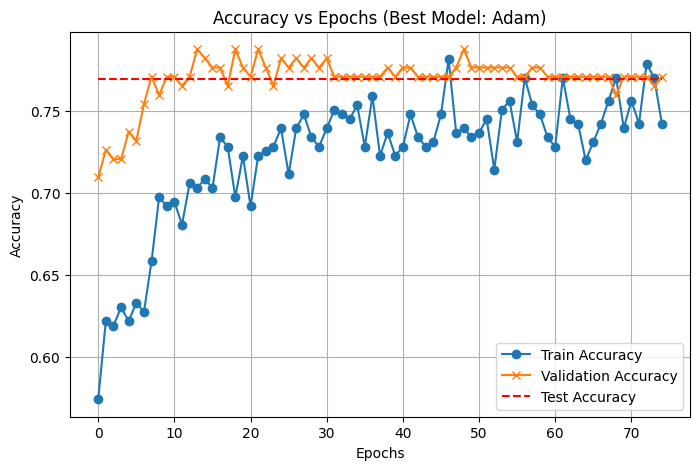

In [ ]:



epochs = len(history['train_acc'])

test_acc_line = np.full(epochs, test_acc)
test_loss_line = np.full(epochs, test_loss_val)


plt.figure(figsize=(8,5))
plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', marker='x')
plt.hlines(test_acc, 0, epochs-1, colors='r', linestyle='--', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Epochs (Best Model: {best_optimizer_name})')
plt.legend()
plt.grid(True)
plt.show()




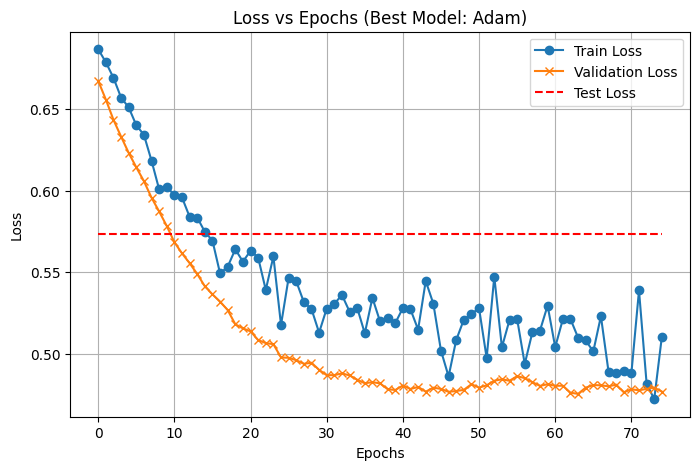

In [ ]:
# --- Loss plot ---
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='x')
plt.hlines(test_loss_val, 0, epochs-1, colors='r', linestyle='--', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'Loss vs Epochs (Best Model: {best_optimizer_name})')
plt.legend()
plt.grid(True)
plt.show()

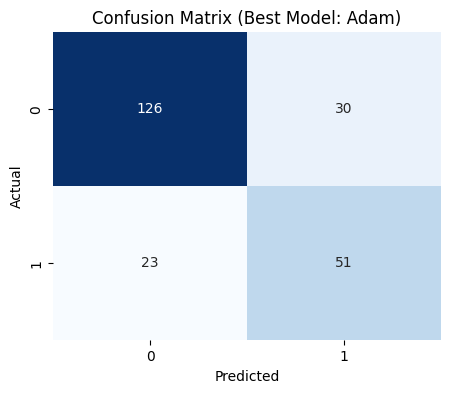

In [ ]:

best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = best_model(X_batch).squeeze()
        preds = torch.round(torch.sigmoid(logits))
        all_preds.append(preds)
        all_labels.append(y_batch)

# Convert to single arrays
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Best Model: {best_optimizer_name})')
plt.show()


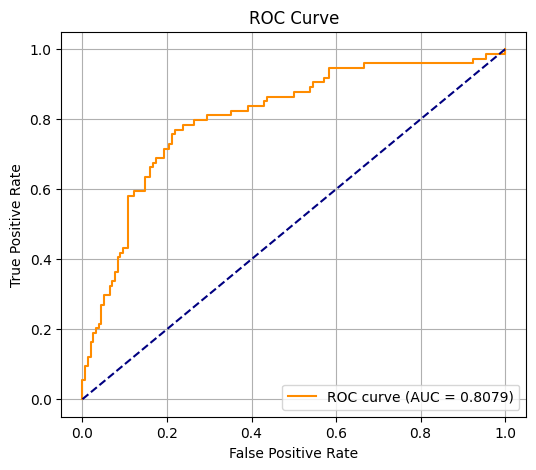

In [ ]:
#ROC
y_test_true = all_labels
y_test_pred_probs = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = best_model(X_batch).squeeze()
        probs = torch.sigmoid(logits)
        y_test_pred_probs.append(probs)

y_test_pred_probs = torch.cat(y_test_pred_probs).numpy()

fpr, tpr, thresholds = roc_curve(y_test_true, y_test_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

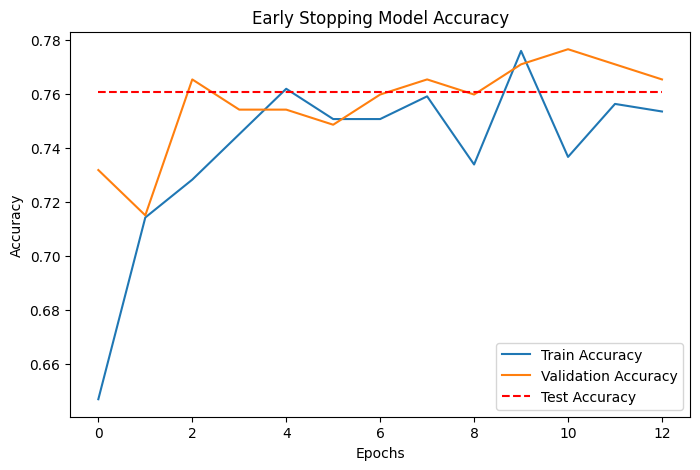

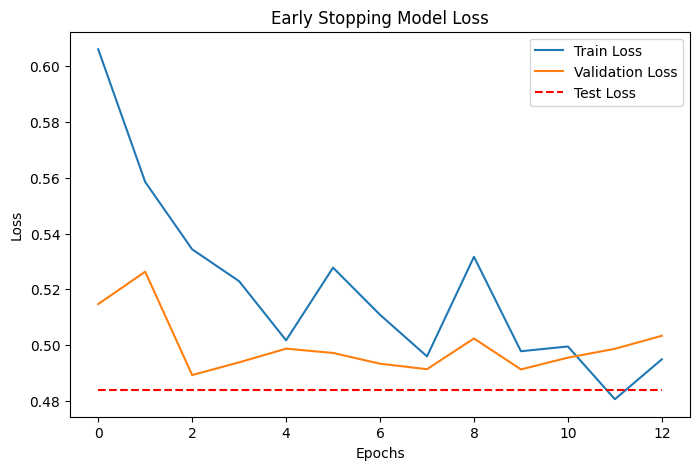

In [ ]:

epochs = len(early_history['train_acc'])


test_acc_line = np.full(epochs, early_test_acc)
test_loss_line = np.full(epochs, early_test_loss)

# ----- Accuracy Plot -----
plt.figure(figsize=(8,5))
plt.plot(range(epochs), early_history['train_acc'], label='Train Accuracy')
plt.plot(range(epochs), early_history['val_acc'], label='Validation Accuracy')
plt.plot(range(epochs), test_acc_line, '--', color='r', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Early Stopping Model Accuracy')
plt.legend()
plt.show()

# ----- Loss Plot -----
plt.figure(figsize=(8,5))
plt.plot(range(epochs), early_history['train_loss'], label='Train Loss')
plt.plot(range(epochs), early_history['val_loss'], label='Validation Loss')
plt.plot(range(epochs), test_loss_line, '--', color='r', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Early Stopping Model Loss')
plt.legend()
plt.show()

In [ ]:
#saving early stopping weight because it gave us the best test accuracy of 78 %
torch.save(early_trained_model.state_dict(), "a2_part_2_pradeep_aniket.pth")

with open("a2_part_2_pradeep_aniket.pkl", "wb") as f:
    pickle.dump(early_trained_model.state_dict(), f)
print("Early Stopping- Best Model Weights Saved as 'a2_part_2_pradeep_aniket.pth and a2_part_1_pradeep_aniket.pkl'")



Early Stopping- Best Model Weights Saved as 'a2_part_2_pradeep_aniket.pth and a2_part_1_pradeep_aniket.pkl'


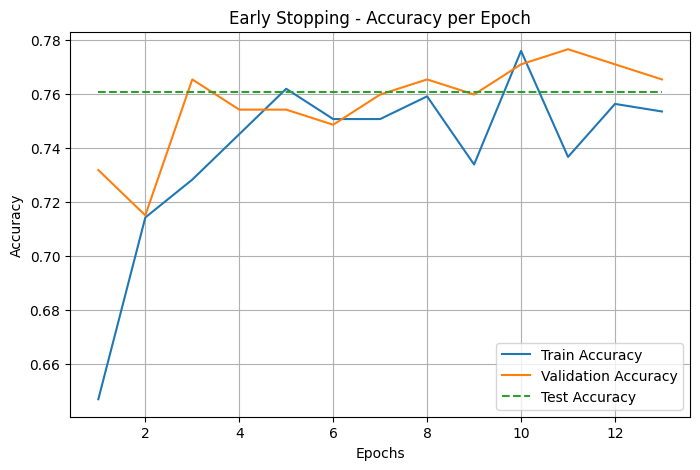

In [ ]:
epochs = len(early_history['train_acc'])
train_acc_line = early_history['train_acc']
val_acc_line = early_history['val_acc']
test_acc_line = np.full(epochs, early_test_acc)  # repeat test accuracy

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_acc_line, label='Train Accuracy')
plt.plot(range(1, epochs+1), val_acc_line, label='Validation Accuracy')
plt.plot(range(1, epochs+1), test_acc_line, label='Test Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Early Stopping - Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()

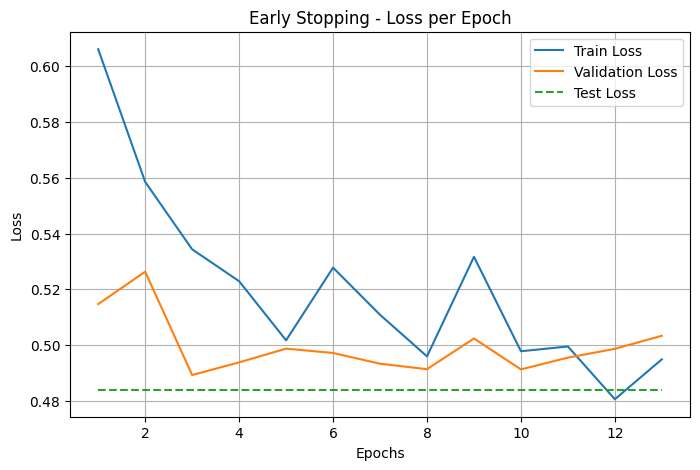

In [ ]:
train_loss_line = early_history['train_loss']
val_loss_line = early_history['val_loss']
test_loss_line = np.full(epochs, early_test_loss)
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_loss_line, label='Train Loss')
plt.plot(range(1, epochs+1), val_loss_line, label='Validation Loss')
plt.plot(range(1, epochs+1), test_loss_line, label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Early Stopping - Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

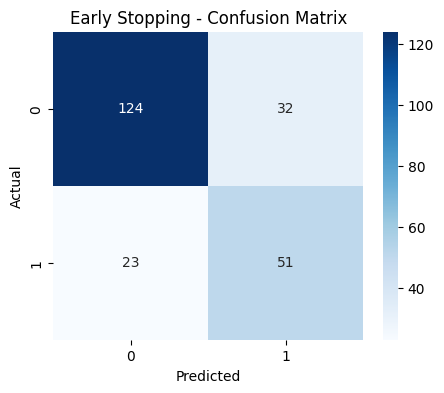

In [ ]:
early_trained_model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = early_trained_model(X_batch).squeeze()
        preds = torch.round(torch.sigmoid(logits))
        y_true.extend(y_batch.tolist())
        y_pred.extend(preds.tolist())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Early Stopping - Confusion Matrix')
plt.show()

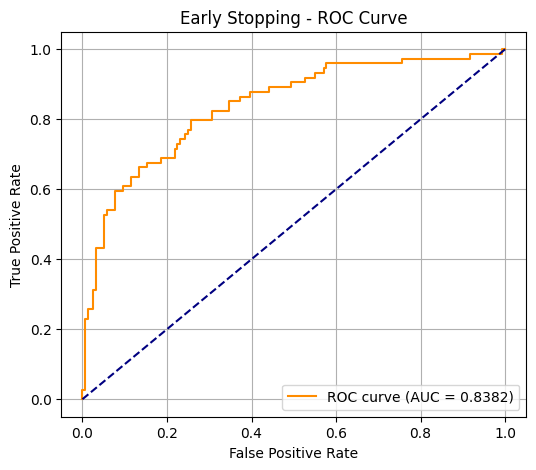

In [ ]:
y_prob = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = early_trained_model(X_batch).squeeze()
        y_prob.extend(torch.sigmoid(logits).tolist())

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Early Stopping - ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Observation

##Accuracy Plot Analysis
1> With the increase in epoch model is learning pattern in the training set

2> Validation accuracy is fluctuating initially but stabilizes towards the later epoch

3> test accuracy is above the validation accuracy



##Loss Plot Analysis
1> Training loss is decreasing steadily which states that model is actually learning and minimizing the loss  on the training data

2> Validation loss is fluctuating in the start but it stabilizes as the epoch count increases

3> Test loss is the lowest representing it aligns well with the validation loss


##ROC curve
AUC is 0.8382 indicating our model has good discriminative ability representing False Positive Rate vs True Positive Rate over the number of epochs

